In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path("notebooks/26May4-PyramidForcing-multihead")
if NOTEBOOK_DIR.exists():
    PROJECT_ROOT = Path(".").resolve()
else:
    NOTEBOOK_DIR = Path(".").resolve()
    PROJECT_ROOT = NOTEBOOK_DIR.parents[1]


In [4]:
HEAD_INDEX_START = 36
HEAD_INDEX_END = 156

FIGURE_SIZE = (3.04, 1.65)
DPI = 600

OUTPUT_DIR = PROJECT_ROOT / "figures/26May4-PyramidForcing-multihead"
CSV_PATH = OUTPUT_DIR / "head_period_homology_256_firstdiff_folded_top1_0_68.csv"


Selected 120 rows for head_index 36-155.
Saved figure to /home/winbeau/Tools/jupyter-plot/figures/26May4-PyramidForcing-multihead/head_period_homology_headindex_window_36_156_mean_std.png
Saved figure to /home/winbeau/Tools/jupyter-plot/figures/26May4-PyramidForcing-multihead/head_period_homology_headindex_window_36_156_mean_std.pdf


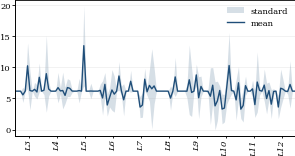

In [5]:
if HEAD_INDEX_START < 0:
    raise ValueError(f"HEAD_INDEX_START must be >= 0; got {HEAD_INDEX_START}")
if HEAD_INDEX_END > 360:
    raise ValueError(f"HEAD_INDEX_END must be <= 360; got {HEAD_INDEX_END}")
if HEAD_INDEX_START >= HEAD_INDEX_END:
    raise ValueError(
        "HEAD_INDEX_START must be smaller than HEAD_INDEX_END for the "
        f"right-open interval; got {HEAD_INDEX_START}:{HEAD_INDEX_END}"
    )

if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV_PATH does not exist: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
required_columns = {"layer", "head", "head_index", "period_mean", "period_std"}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise ValueError(f"CSV_PATH is missing required columns: {missing_columns}")

df = df.sort_values("head_index").reset_index(drop=True)
window_df = df[
    (df["head_index"] >= HEAD_INDEX_START)
    & (df["head_index"] < HEAD_INDEX_END)
].copy()
if window_df.empty:
    raise ValueError(
        "No rows selected from CSV_PATH for head_index interval "
        f"[{HEAD_INDEX_START}, {HEAD_INDEX_END})"
    )

window_df = window_df.sort_values("head_index").reset_index(drop=True)
x = np.arange(len(window_df), dtype=np.float64)
mean = window_df["period_mean"].to_numpy(dtype=np.float64)
std = window_df["period_std"].to_numpy(dtype=np.float64)
lower = mean - std
upper = mean + std

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
        "font.size": 8,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 2.0,
        "ytick.major.size": 2.0,
        "savefig.dpi": 600,
        "savefig.bbox": None,
        "savefig.pad_inches": 0,
    }
)

fig, ax = plt.subplots(figsize=FIGURE_SIZE, constrained_layout=True)
color = "#1f4e79"
ax.fill_between(x, lower, upper, color=color, alpha=0.18, linewidth=0, label="standard")
ax.plot(x, mean, color=color, marker=None, linewidth=1.0, label="mean")

layer_ticks_all = []
layer_labels_all = []
for layer, layer_df in window_df.groupby("layer", sort=True):
    positions = layer_df.index.to_numpy(dtype=np.float64)
    layer_ticks_all.append((positions[0] + positions[-1]) / 2.0)
    layer_labels_all.append(f"L{int(layer)}")
label_stride = max(1, int(np.ceil(len(layer_ticks_all) / 10)))
layer_ticks = layer_ticks_all[::label_stride]
layer_labels = layer_labels_all[::label_stride]

ax.set_xlim(-0.4, len(window_df) - 0.6)
ax.set_xticks(layer_ticks)
ax.set_xticklabels(layer_labels, rotation=90, ha="center", fontsize=6, fontstyle="italic")
ax.tick_params(axis="x", pad=1, length=1.5)
ax.tick_params(axis="y", pad=1)
ax.grid(True, axis="y", alpha=0.28, linewidth=0.4)
ax.legend(loc="upper right", fontsize=6, frameon=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.6)
    spine.set_clip_on(False)
border_inset = 0.0015
ax.add_patch(
    mpl.patches.Rectangle(
        (border_inset, border_inset),
        1 - 2 * border_inset,
        1 - 2 * border_inset,
        transform=ax.transAxes,
        fill=False,
        edgecolor="black",
        linewidth=0.6,
        clip_on=False,
        zorder=10,
    )
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_stem = OUTPUT_DIR / (
    "head_period_homology_headindex_window_"
    f"{HEAD_INDEX_START}_{HEAD_INDEX_END}_mean_std"
)
png_path = output_stem.with_suffix(".png")
pdf_path = output_stem.with_suffix(".pdf")
with mpl.rc_context({"savefig.bbox": None, "savefig.pad_inches": 0}):
    fig.savefig(png_path, dpi=DPI, bbox_inches=None, pad_inches=0)
    fig.savefig(pdf_path, dpi=DPI, bbox_inches=None, pad_inches=0)

print(
    f"Selected {len(window_df)} rows for head_index "
    f"{int(window_df['head_index'].min())}-{int(window_df['head_index'].max())}."
)
print(f"Saved figure to {png_path}")
print(f"Saved figure to {pdf_path}")

if "agg" in plt.get_backend().lower():
    plt.close(fig)
else:
    plt.show()
